# outliers and its treatment


outliers are extreme values 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

In [3]:
salary = [11, 40, 45, 68, 65, 68, 78, 90, 57, 74, 91, 92, 88, 68, 57, 48, 99, 101, 68, 77, 110, 140]
salary

[11,
 40,
 45,
 68,
 65,
 68,
 78,
 90,
 57,
 74,
 91,
 92,
 88,
 68,
 57,
 48,
 99,
 101,
 68,
 77,
 110,
 140]

In [4]:
# five point summary
# min, 25th , 50th ,75th, and 100th percentile

In [5]:
np.quantile(salary, [0,0.25,0.50,0.75,1])

array([ 11.  ,  59.  ,  71.  ,  90.75, 140.  ])

In [6]:
df= pd.DataFrame(salary , columns = ['salary'])
df

,salary
0,11
1,40
2,45
3,68
4,65
5,68
6,78
7,90
8,57
9,74


In [7]:
df.describe()

,salary
count,22.000000
mean,74.318182
std,27.201867
min,11.000000
25%,59.000000
50%,71.000000
75%,90.750000
max,140.000000


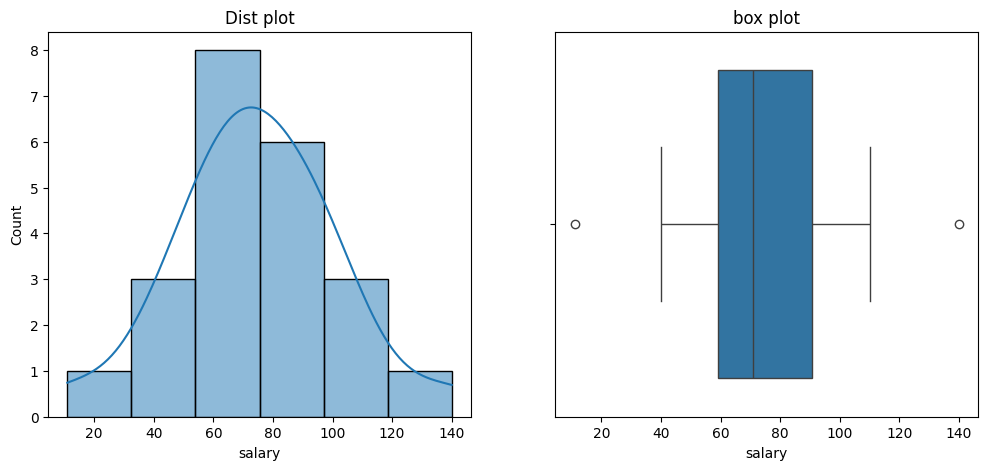

In [8]:
# to check outliers >> distplot , boxplot

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['salary'] , kde = True)
plt.title("Dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=df, x ='salary')
plt.title("box plot")
plt.show()

In [9]:
#here the distribution is not skewed as the outliers are present on both side
#In box plot, we see there are outliers

#dropping the outlier

#replace with mean and median

#capping the outlier

In [10]:
# dropping the outliers

Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)

IQR = Q3-Q1

lower_fence =  Q1 - 1.5*IQR
upper_fence =  Q3 + 1.5*IQR

In [11]:
df_filter = df[(df.salary >= lower_fence) & (df.salary <= upper_fence)]
df_filter

,salary
1,40
2,45
3,68
4,65
5,68
6,78
7,90
8,57
9,74
10,91


In [12]:
df.shape

(22, 1)

In [13]:
df_filter.shape

(20, 1)

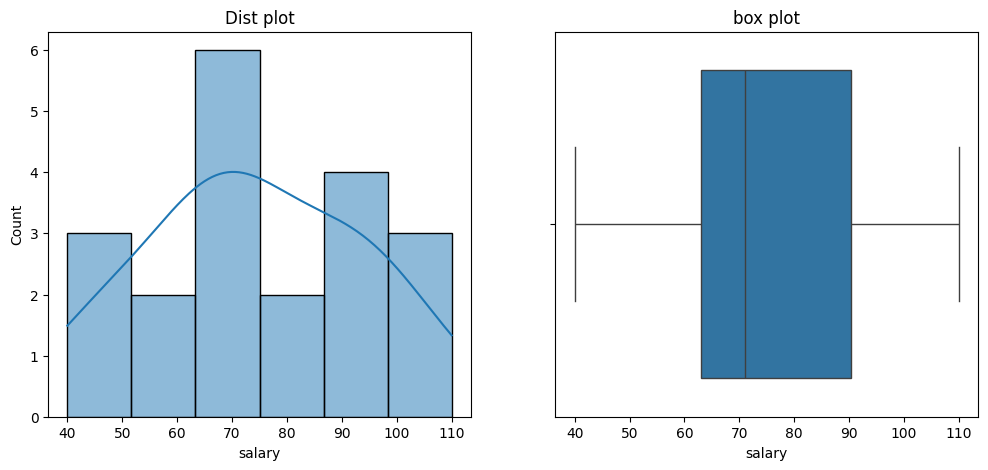

In [14]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df_filter['salary'] , kde = True)
plt.title("Dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=df_filter, x ='salary')
plt.title("box plot")
plt.show()

In [15]:
#  imputation with mean

df["salary_imputed_mean"] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].mean(), df['salary'])

In [16]:
df

,salary,salary_imputed_mean
0,11,74.318182
1,40,40.000000
2,45,45.000000
3,68,68.000000
4,65,65.000000
5,68,68.000000
6,78,78.000000
7,90,90.000000
8,57,57.000000
9,74,74.000000


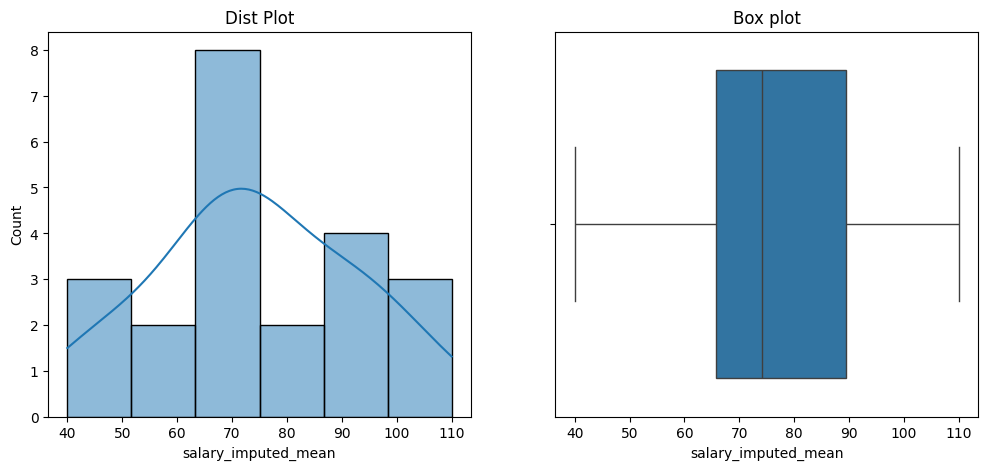

In [17]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_imputed_mean'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_imputed_mean')
plt.title("Box plot")
plt.show()

In [18]:
#imputation with median
df['salary_impuuted_median'] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].median(), df['salary'])

In [19]:
df

,salary,salary_imputed_mean,salary_impuuted_median
0,11,74.318182,71.0
1,40,40.000000,40.0
2,45,45.000000,45.0
3,68,68.000000,68.0
4,65,65.000000,65.0
5,68,68.000000,68.0
6,78,78.000000,78.0
7,90,90.000000,90.0
8,57,57.000000,57.0
9,74,74.000000,74.0


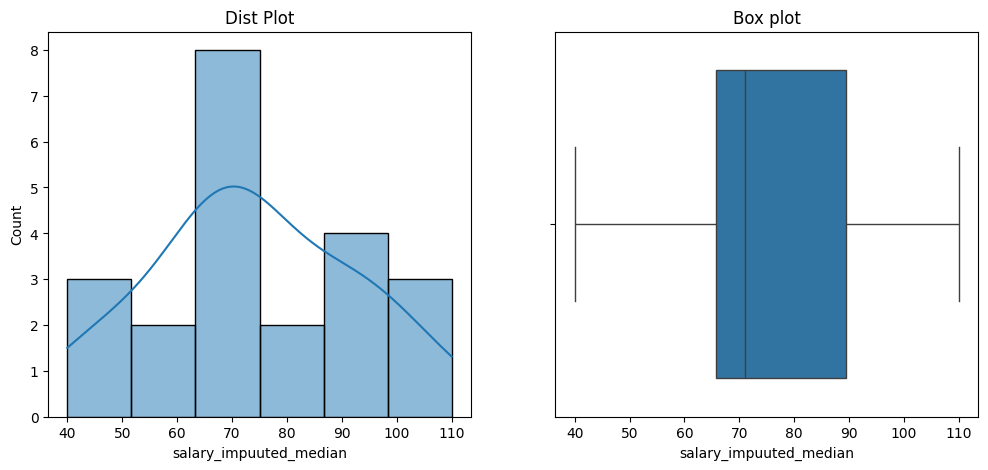

In [20]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_impuuted_median'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_impuuted_median')
plt.title("Box plot")
plt.show()

#capping >> replacing the nearest value which is not outlier

In [21]:
df

,salary,salary_imputed_mean,salary_impuuted_median
0,11,74.318182,71.0
1,40,40.000000,40.0
2,45,45.000000,45.0
3,68,68.000000,68.0
4,65,65.000000,65.0
5,68,68.000000,68.0
6,78,78.000000,78.0
7,90,90.000000,90.0
8,57,57.000000,57.0
9,74,74.000000,74.0


In [22]:
lower_cap = df['salary'].quantile(0.05)  # lower cap is 5th percentile
upper_cap = df['salary'].quantile(0.95)  # upper cap is 95th percentile

In [23]:
print(lower_cap)
print(lower_fence)
print(upper_cap)
print(upper_fence)

40.25
11.375
109.55
138.375


In [27]:
#replace outliers with cap
# where(condition, [x, y], /)
# Return elements chosen from `x` or `y` depending on `condition`.
#if df['Salary'] < lower_cap satisfied then lower_cap and df['Salary']>upper_cap satisfied then upper_cap
#otherwise keep Salary as it is

df['salary_capped'] = np.where(df['salary'] < lower_cap , lower_cap ,
                               np.where(df['salary']> upper_cap, upper_cap , df["salary"]))

In [28]:
df

,salary,salary_imputed_mean,salary_impuuted_median,salary_capped
0,11,74.318182,71.0,40.25
1,40,40.000000,40.0,40.25
2,45,45.000000,45.0,45.00
3,68,68.000000,68.0,68.00
4,65,65.000000,65.0,65.00
5,68,68.000000,68.0,68.00
6,78,78.000000,78.0,78.00
7,90,90.000000,90.0,90.00
8,57,57.000000,57.0,57.00
9,74,74.000000,74.0,74.00


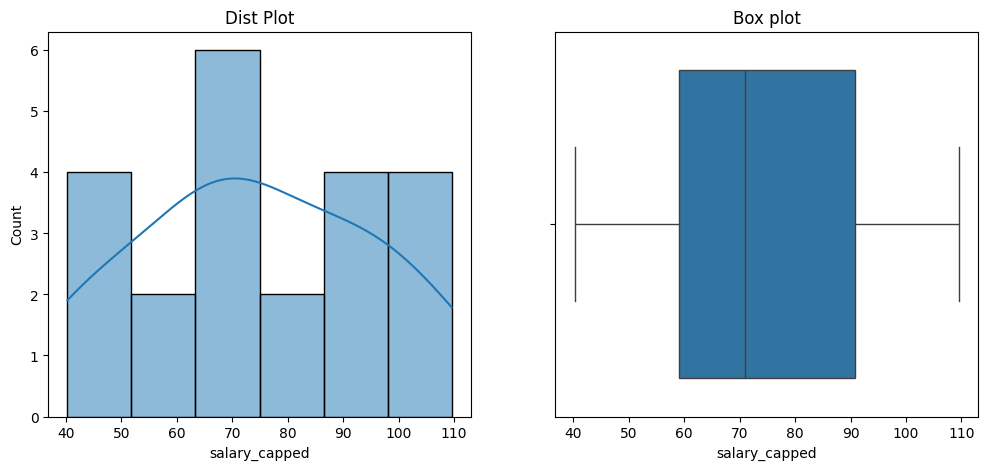

In [29]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_capped'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_capped')
plt.title("Box plot")
plt.show()